# Prompting
+ El prompting es el proceso de proporcoinar instrucciones o contexto a un modelo de lenguaje para guiar su respuesta. Consiste en formular una entrada (prompt) que el modelo utiliza para generar una salida deseada.

![Captura de pantalla 2026-03-16 031500.png](<attachment:Captura de pantalla 2026-03-16 031500.png>)
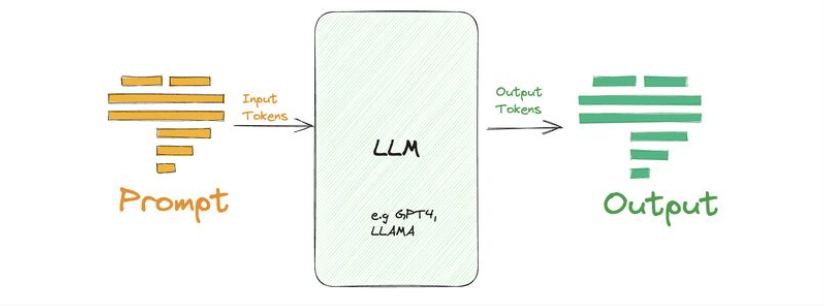



## Del Entrenamiento al Prompting

+ Históricamente, para que un modelo aprenda una tarea nueva era necesario el Fine-Tuning:Entrenarlo con datos especificos, lento y costoso. 
Con la aparición de los LLMs (Large Language Models), pasamos al paradigma del Prompting: Interactuamos con modelos de lenguaje (LLMs) con lenguaje natural

+ Ventajas del Fine-Tuning:
    + El modelo se vuelve más preciso en la tarea específica
    + Aprovecha el conocimiento general del modelo original, ahorrando tiempo y recursos.
+ In Context Learning
    + Permite al modelo adaptarse a nuevas tareas rápidamente.
    + No requiere recursos computacionales adicionales para el entrenamiento.
    
## Tokens 
+ Son las unidades básicas de procesamiento. Muchas palabras se mapean a un token, pero otras son indivisibles. Por ejemplo, caracteres especiales o emojis pueden dividirse en múltiples tokens.
+ Por qué importa
    + Precio distintos para token de entrada vs salida
    + La ventana de contexto
    + Los limites de un plan de suscripcion

![Captura de pantalla 2026-03-16 032552.png](<attachment:Captura de pantalla 2026-03-16 032552.png>)
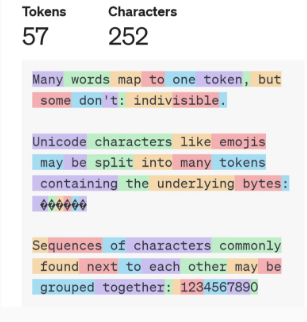

## Context Window (Ventana de Contexto)
+ Funciona como una "memoria de corto plazo" (short-term memory). Es el límite de información que el modelo puede "recordar" o procesar en un mismo turno de conversación.
+ Por qué importa
    + Existe un limite.
    + En un agente entran cosas “invisibles”:
        + Ststem prompt
        + Archivos que leyó
        + Tokens de rezonamiento 
        + Documentacion que ubsca en un sitio
    + El agente contesta con lo que tiene dentro de la ventana
    + Cuanto mas llena (sin llegar al limite), baja la performance
    + Costo

+ Equilibrio entre meter todo lo necesario para que funcione bien, pero sin pasarme lo cual genera mas costo y baja performace.

![Captura de pantalla 2026-03-16 035158.png](<attachment:Captura de pantalla 2026-03-16 035158.png>)

## Como se "cansa" el modelo?
+ Si llenamos el prompt con información irrelevante o instrucciones contradictorias, el modelo sufre una carga cognitiva excesiva
    + Alucinaciones: El modelo empieza a inventar datos o funciones de Python que no existen.
    + Pérdida de foco: La IA olvida las primeras instrucciones para priorizar las últimas.
    + Código ineficiente: Empieza a sugerir soluciones complejas (como bucles innecesarios) en lugar de código simple y directo.

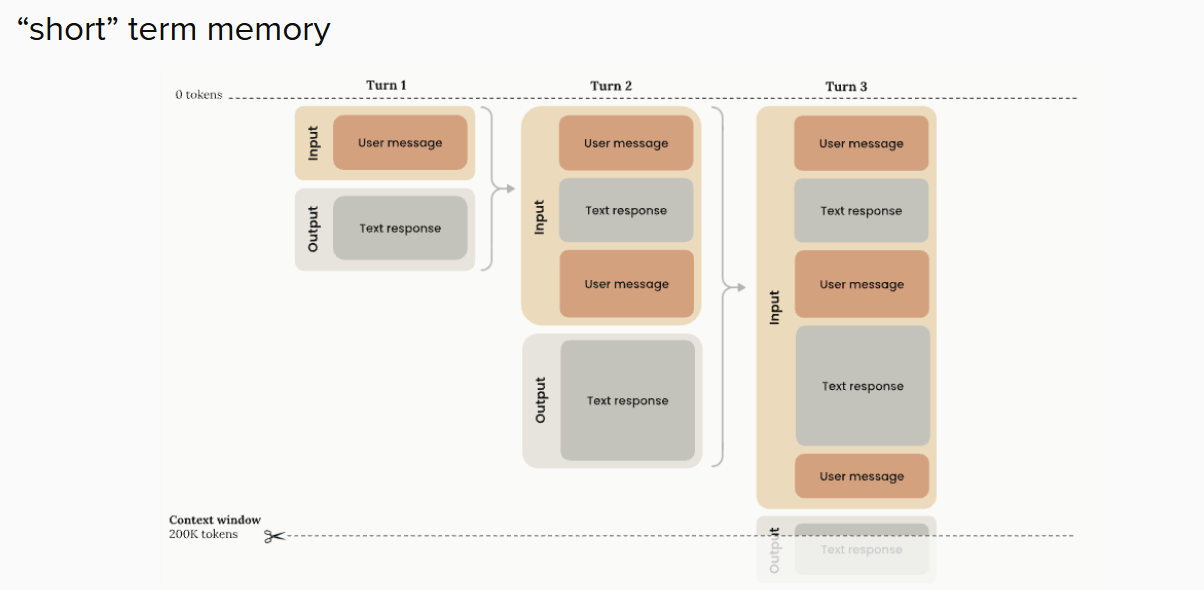

## Del Entrenamiento al Prompting
+ Para optimizar el uso del modelo y evitar el desperdicio de tokens y por lo tanto, de alucinaciones o imprecisiones tenemos que pensar al prompt en 6 componentes ordenadores:
    + 1. Tarea (Task): Es el objetivo central. Debe comenzar siempre con un verbo de acción (ej: Generar, Analizar, Resumir).
    + 2. Contexto: Es el trasfondo de la solicitud. Definimos qué datos tenemos disponibles y cuál es el objetivo final del análisis.
    + 3. Persona: Define qué rol o profesión debe adoptar la IA (ej: "Actuá como un experto en visualización de datos electorales").
    + 4. Ejemplos (Shots): Proporcionar muestras del resultado esperado para que el modelo aprenda sobre la marcha (In-Context Learning).
    + 5. Formato: Determina cómo se debe visualizar el resultado (ej: un bloque de código de Python, una tabla de Markdown, un archivo CSV).
    + 6. Tono: Define la personalidad y el nivel de tecnicismo de la respuesta (ej: conciso, técnico, académico).
    + Estos componentes están ordenados de mas importante a mas opcional. Un prompt completo tendrá idealmente a todos los pasos.

+ La tarea y el contexto son fundamentales. Si estas dos partes fallan, el output va a ser malo. 
    + La tarea tiene que ser precisa y delimitada, si es muy compleja, dividir en subtareas para no agotar la ventana de contexto.
    + El contexto tiene que delimitar el universo de datos. Mencionar qué librerías estamos usando y la estructura de nuestro DataFrame.

![Captura de pantalla 2026-03-16 040402.png](<attachment:Captura de pantalla 2026-03-16 040402.png>)
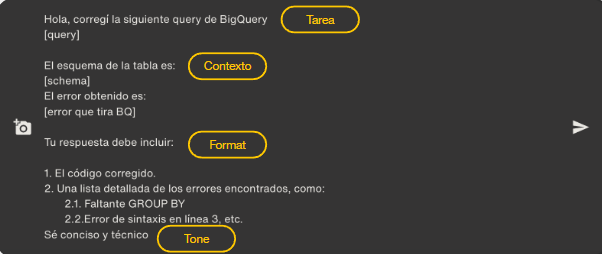

## Ejemplos
### Mal Prompt
    "Haceme un gráfico con los votos de las agrupaciones"
### Buen Prompt
    "Actuá como un analista de datos que prefiere código simple y directo. Tengo un DataFrame llamado votos_partidos con las columnas NOMBRE_AGRUPACION y VOTOS_AGRUPACION. Ya importé matplotlib.pyplot como plt.La tarea es generar el código para un gráfico de barras. Solo devolvé el código. No uses funciones (def) ni clases."

## Tecnicas de optimización y razonamiento
+ Para resolver problemas más complejos que un simple gráfico, como la limpieza de strings o la normalización de categorías electorales, no basta con una instrucción directa. Necesitamos usar técnicas que guíen el proceso de "pensamiento" del modelo.
    ## Estrategias de "Shots"
    + Zero-shot: El modelo realiza una tarea sin ejemplos previos, solo con una instrucción.
    + One-shot: Se proporciona un solo ejemplo junto con la instrucción.
    + Few-shot: Se proporcionan dos o tres ejemplos del par "Input -> Output" deseado. Es la técnica más efectiva para que la IA aprenda nuestra sintaxis de programación específica dentro de la ventana de contexto.

    ## Chain-of-Thought (CoT)
    + Esta técnica consiste en pedirle al modelo que "piense en voz alta" antes de entregar el código final. Al obligar a la IA a descomponer el problema en pasos lógicos, reducimos drásticamente los errores en tareas de transformación de datos.

    ### Ejemplo
    + Supongamos que tenemos una columna con nombres de partidos escritos de forma inconsistente y queremos normalizarlos.
    "Trabajo con un DataFrame de pandas con la columna partido_sucio. [Contexto]
    Normalizar los nombres de los partidos a sus nombres oficiales.[Tarea] 
    Pensá paso a paso: 1. Identificá el partido, 2. Definí el nombre oficial, 3. Escribí el código usando un diccionario y .map(). [Instrucción]
    Ejemplos: 
    "Fren. de Tod." -> "FRENTE DE TODOS"
    "Junt. x el Cam." -> "JUNTOS POR EL CAMBIO"
    Solo devolvé el código final. No uses funciones complejas. [Formato]"
    + Respuesta del prompt: 

In [16]:
import pandas as pd

# Contexto: Creamos el DataFrame de prueba para que la celda sea autocontenida
data = {
    'partido': ['Fren. de Tod.', 'Junt. x el Cam.', 'Cons. Fed.', 'Fren. de Tod.']
}
df = pd.DataFrame(data)

# Instrucción 1 y 2: Identificación y definición de nombres oficiales
limpieza = {
    'Fren. de Tod.': 'FRENTE DE TODOS',
    'Junt. x el Cam.': 'JUNTOS POR EL CAMBIO',
    'Cons. Fed.': 'CONSENSO FEDERAL'
}

# Instrucción 3: Aplicación del código usando .map()
df['partido_normalizado'] = df['partido'].map(limpieza)

# Resultado
df

,partido,partido_normalizado
0,Fren. de Tod.,FRENTE DE TODOS
1,Junt. x el Cam.,JUNTOS POR EL CAMBIO
2,Cons. Fed.,CONSENSO FEDERAL
3,Fren. de Tod.,FRENTE DE TODOS


  ## Chain-of-Thought (CoT)
 
  + A diferencia de Chain of Thought (que sigue una línea única de razonamiento), Tree of Thoughts permite al modelo explorar múltiples caminos en paralelo para resolver un problema.
  + Funcionamiento: El modelo genera varias ideas o "pensamientos" independientes, los evalúa y selecciona el camino más sólido para avanzar
  + Gestión de Tokens: Esta técnica es significativamente más pesada en términos de tokens. Al generar y evaluar múltiples rutas, la ventana de contexto se llena más rápido, lo que puede acelerar la "fatiga" del modelo si no se delimita bien la tarea principal.

![Captura de pantalla 2026-03-16 110156.png](<attachment:Captura de pantalla 2026-03-16 110156.png>)


  ### Ejemplo
  + Cuando trabajamos con datasets complejos (como el Censo 2010), no siempre hay una única forma de tratar datos nulos. Podemos usar ToT para que la IA evalúe opciones antes de programar.
    "Proponé 3 métodos para manejar valores nulos en la columna INGRESOS de un dataset de hogares. Analizá cada método según si sesga o no los resultados estadísticos. Elegí el método más neutral y generá el código de Python necesario. Usamos pandas. El DataFrame se llama df_hogar."
  + Al usar ToT, estamos orquestando el pensamiento del modelo para que actúe como un filtro de calidad antes de escribir una sola línea de código. - Su uso es más costoso.
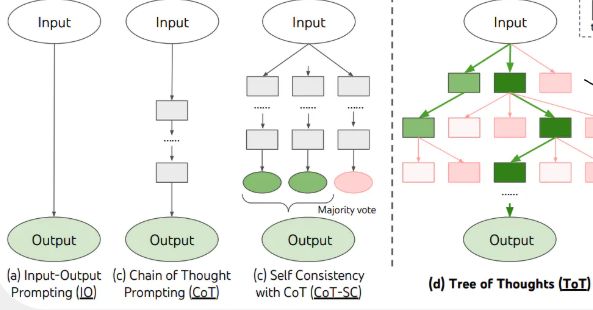

## Resumen para un buen prompt
+ Ser directo, evitar la complejidad y expresar la solicitud en un lenguaje breve. Utilizar instrucciones positivas.
+ Incluir todos los componentes necesarios. Podes pedirle al LLM que chequee las condiciones.
+ Ordenar los componentes del prompt usando separadores
+ Incluir ejemplos o "shots."
+ Descompone tareas complejas en subtareas y enumeralas en el prompt (en uno o en varios prompts sucesivos)
+ Instrui al modelo para que desarrolle su propia solución, pidiéndole que razone paso a paso.